In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nowrinbegumr/walmart-sales-forcasting-dataset/Walmart_Store_sales.csv


In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [3]:
df=pd.read_csv('/kaggle/input/datasets/nowrinbegumr/walmart-sales-forcasting-dataset/Walmart_Store_sales.csv')

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
print(df.columns)

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [7]:
df['Store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [8]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

In [9]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


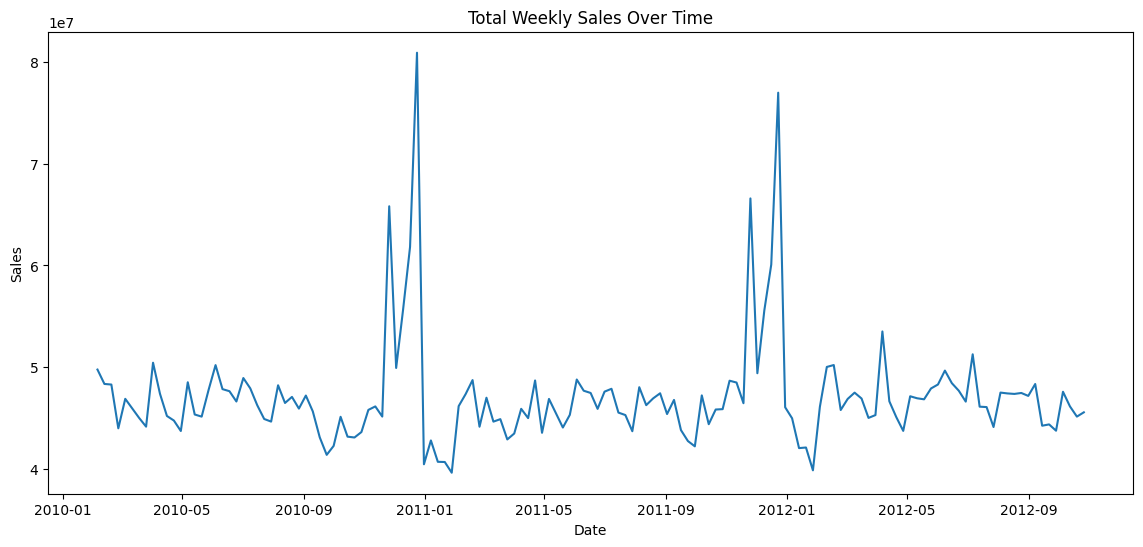

In [10]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(sales_trend)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

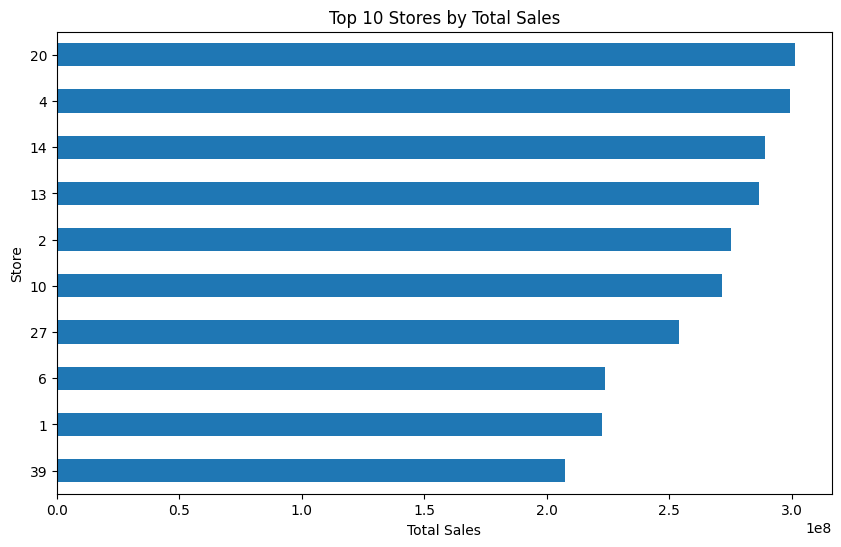

In [11]:
top10 = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Total Sales")
plt.show()

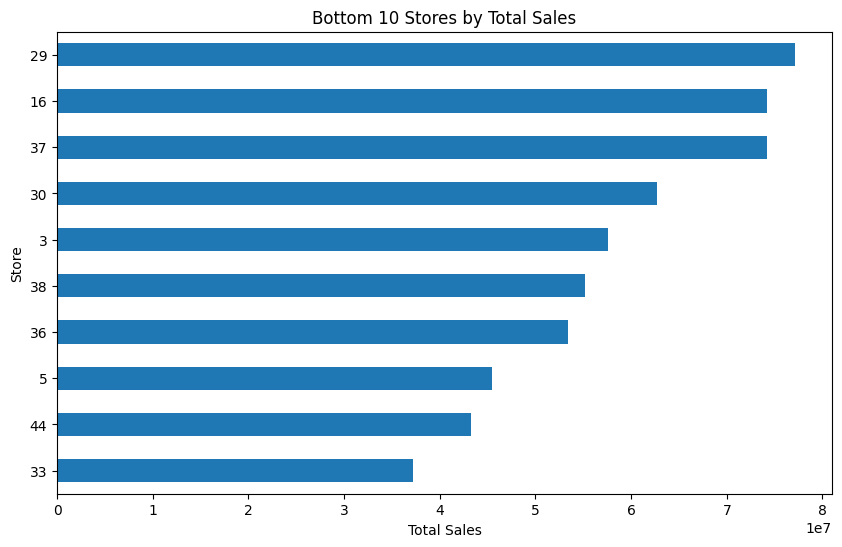

In [12]:
bottom10 = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10,6))
bottom10.plot(kind='barh')

plt.title("Bottom 10 Stores by Total Sales")
plt.xlabel("Total Sales")
plt.show()

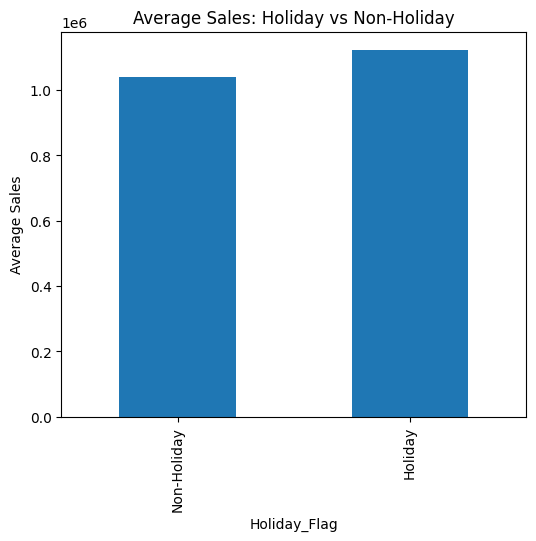

In [13]:
holiday_sales = (
    df.groupby('Holiday_Flag')['Weekly_Sales']
      .mean()
)

plt.figure(figsize=(6,5))
holiday_sales.plot(kind='bar')

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xticks([0,1],['Non-Holiday','Holiday'])
plt.ylabel("Average Sales")
plt.show()

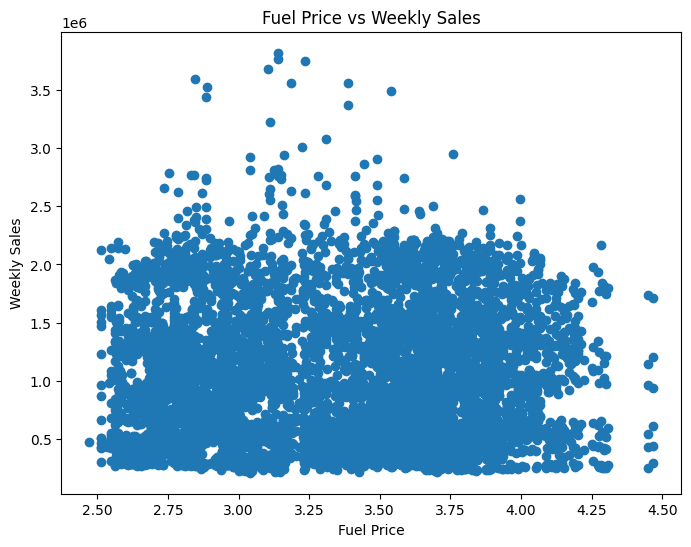

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Fuel_Price'],
    df['Weekly_Sales']
)

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

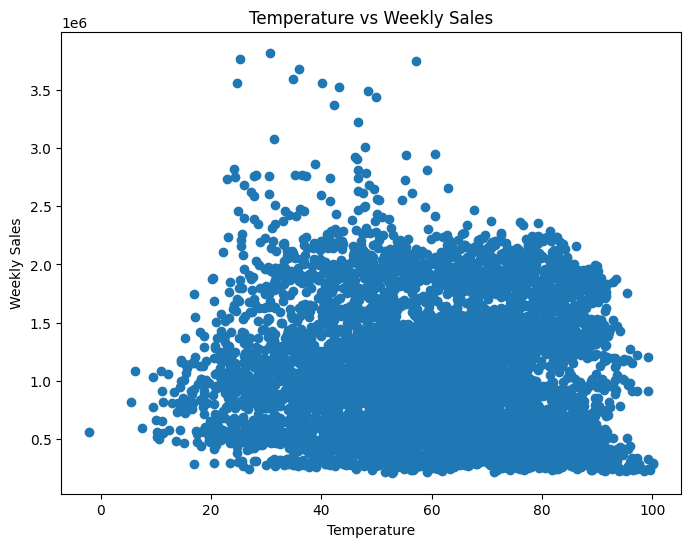

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Temperature'],
    df['Weekly_Sales']
)

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

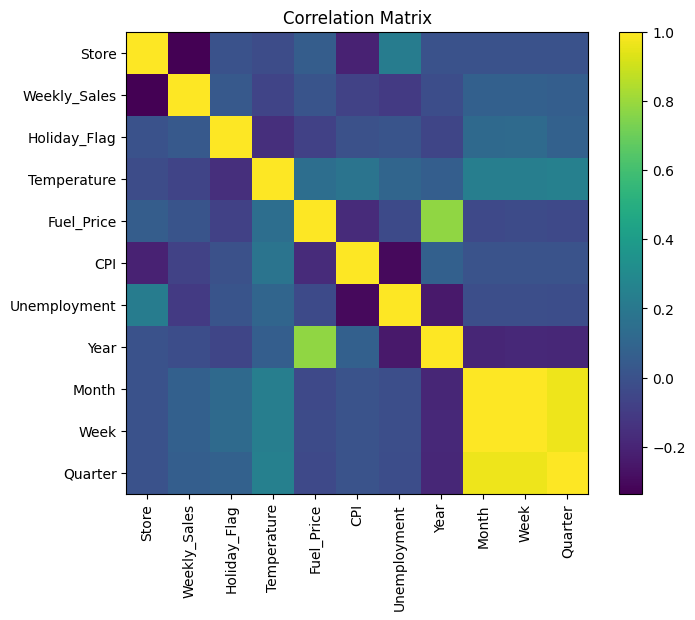

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [17]:
df = df.sort_values(
    ['Store','Date']
)

In [18]:
df['Lag_1'] = (
    df.groupby('Store')['Weekly_Sales']
      .shift(1)
)

df['Lag_4'] = (
    df.groupby('Store')['Weekly_Sales']
      .shift(4)
)

In [19]:
df['Rolling_4'] = (
    df.groupby('Store')['Weekly_Sales']
      .rolling(4)
      .mean()
      .reset_index(0,drop=True)
)

In [20]:
df.dropna(inplace=True)

In [21]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Lag_1,Lag_4,Rolling_4
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,1409727.59,1643690.90,1.554615e+06
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1,1554806.68,1641957.44,1.504011e+06
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1,1439541.59,1611968.17,1.469148e+06
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1,1472515.79,1409727.59,1.467823e+06
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,2,1404429.92,1554806.68,1.477864e+06


In [22]:
features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Week',
    'Quarter',
    'Lag_1',
    'Lag_4',
    'Rolling_4'
]

X = df[features]

y = df['Weekly_Sales']

In [23]:
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

X_train = train[features]
X_test = test[features]

y_train = train['Weekly_Sales']
y_test = test['Weekly_Sales']

In [24]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
pred = model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2  :",r2)

MAE : 37253.36674095607
RMSE: 54740.41173759437
R2  : 0.989589951371818


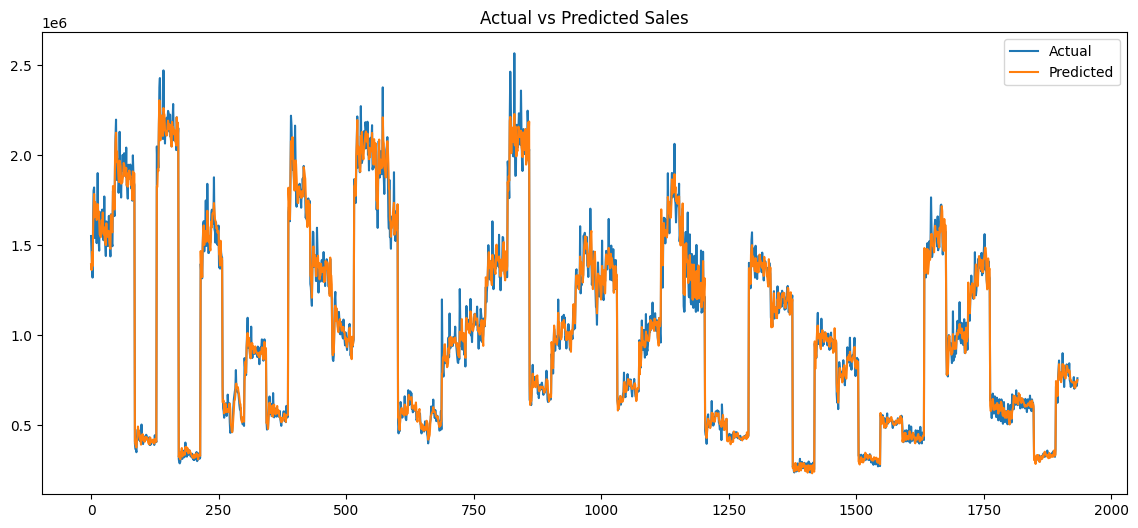

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    pred,
    label='Predicted'
)

plt.title("Actual vs Predicted Sales")

plt.legend()

plt.show()

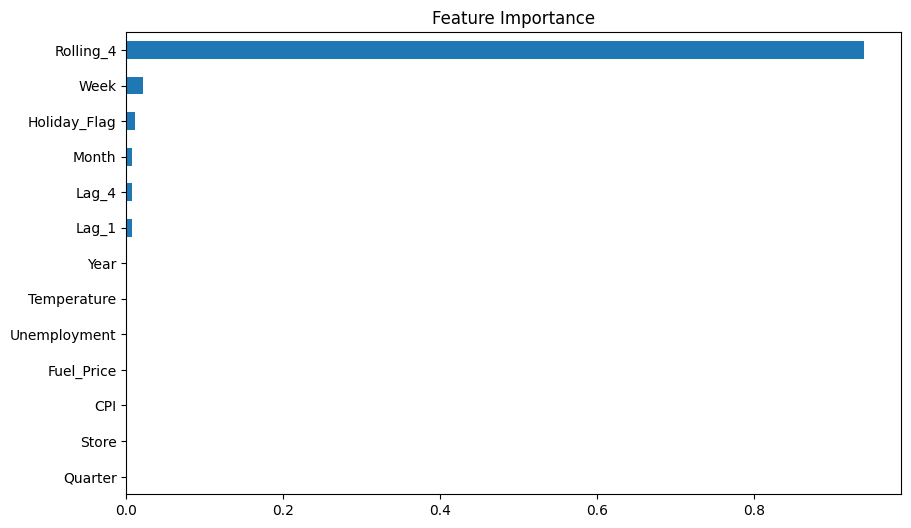

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()

In [29]:
features = [
    'Week',
    'Holiday_Flag',
    'Lag_1',
    'Lag_4',
    'Rolling_4'
]

X = df[features]
y = df['Weekly_Sales']

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
sales_history = list(df['Weekly_Sales'].tail(4))

sales_history

[733455.07, 734464.36, 718125.53, 760281.43]

In [31]:
future_preds = []

current_week = int(df['Week'].iloc[-1])

for i in range(4):

    next_week = current_week + i + 1

    if next_week > 52:
        next_week -= 52

    lag_1 = sales_history[-1]
    lag_4 = sales_history[-4]
    rolling_4 = np.mean(sales_history[-4:])

    X_future = pd.DataFrame({
        'Week':[next_week],
        'Holiday_Flag':[0],
        'Lag_1':[lag_1],
        'Lag_4':[lag_4],
        'Rolling_4':[rolling_4]
    })

    pred = model.predict(X_future)[0]

    future_preds.append(pred)

    sales_history.append(pred)

In [32]:
future_preds

[np.float32(750963.6),
 np.float32(762431.9),
 np.float32(747181.7),
 np.float32(842070.1)]

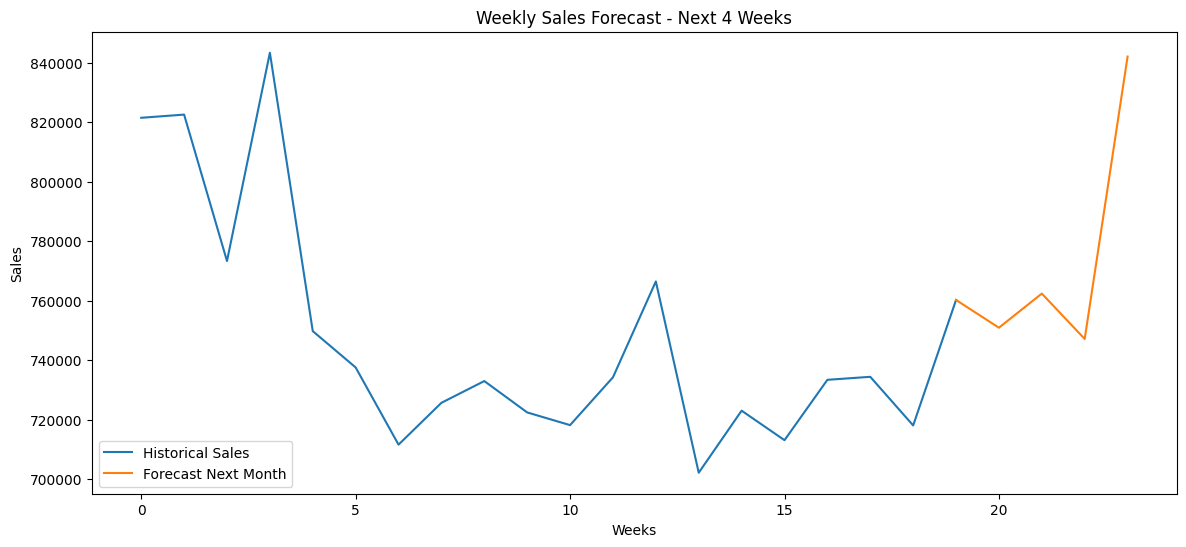

In [33]:
plt.figure(figsize=(14,6))

history = df['Weekly_Sales'].tail(20).values

future = np.array(future_preds)

all_values = np.concatenate([history, future])

x_hist = range(len(history))
x_future = range(len(history)-1, len(all_values))

plt.plot(
    x_hist,
    history,
    label='Historical Sales'
)

plt.plot(
    x_future,
    all_values[len(history)-1:],
    label='Forecast Next Month'
)

plt.title('Weekly Sales Forecast - Next 4 Weeks')
plt.xlabel('Weeks')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [34]:
last_date = df['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=7),
    periods=4,
    freq='W'
)

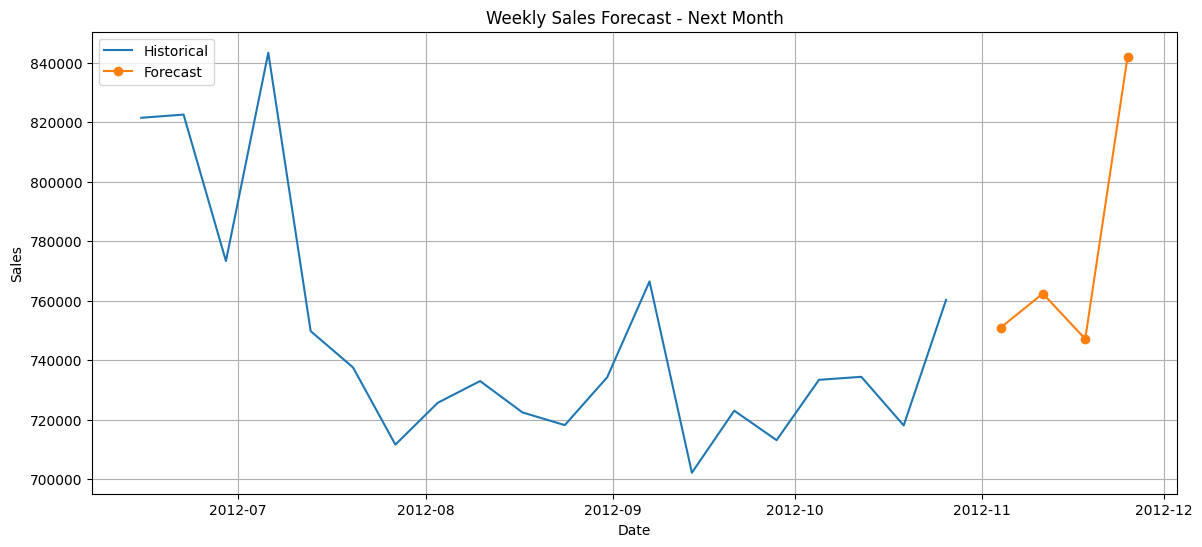

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'].tail(20),
    df['Weekly_Sales'].tail(20),
    label='Historical'
)

plt.plot(
    future_dates,
    future_preds,
    marker='o',
    label='Forecast'
)

plt.title('Weekly Sales Forecast - Next Month')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.grid(True)

plt.show()